# Vegetation mask — Beas Kund (NDVI, three summers)

A static vegetation-vs-bare mask, built on the **same 30 m UTM grid as the
perennial snow pipeline** so the two masks co-register cell-for-cell and can be
combined without resampling.

Multi-sensor — Sentinel-2, Landsat 8, Landsat 9 — per-pixel 90th-percentile NDVI
over clear summer looks from 2022–2024, then a threshold.

**This is not a time series.** Vegetation extent over three years is effectively
static at this scale; the three years exist only to accumulate enough clear looks
to beat monsoon cloud. Stacking years and taking a high per-pixel percentile
gives each pixel *at its greenest* across every clear observation of it — which
is the quantity a vegetation mask actually wants, and is far more robust than any
single date in an AOI this cloudy.

Output codes (`veg_mask.tif`): `1` vegetation · `0` seen, not vegetation ·
`-1` never seen clear.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray
import pystac_client
import planetary_computer
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from rasterio.transform import from_origin
from pyproj import Transformer

# Must match the perennial pipeline exactly, or the masks will not align
BBOX = [77.03373, 32.31549, 77.14879, 32.41271]
UTM  = "EPSG:32643"
RES  = 30.0

YEARS = [2022, 2023, 2024]
WIN   = ("06-15", "09-30")   # peak greenness, post-melt

PCTL     = 90     # per-pixel percentile over clear looks
NDVI_VEG = 0.30   # threshold; sits in the valley of a bimodal histogram (see step 4)

CACHE = Path("../cache_ndvi")
OUT   = Path("../out_ndvi")
(CACHE / "epochs").mkdir(parents=True, exist_ok=True)
OUT.mkdir(exist_ok=True)

SENSORS = {
    "S2": dict(collection="sentinel-2-l2a",
               red="B04", nir="B08", mask="SCL", mask_kind="scl",
               scale=1 / 10000.0, offset=-1000 / 10000.0),
    "L8": dict(collection="landsat-c2-l2", platform="landsat-8",
               red="red", nir="nir08", mask="qa_pixel", mask_kind="qa_pixel",
               scale=0.0000275, offset=-0.2),
    "L9": dict(collection="landsat-c2-l2", platform="landsat-9",
               red="red", nir="nir08", mask="qa_pixel", mask_kind="qa_pixel",
               scale=0.0000275, offset=-0.2),
}

QA_FILL, QA_DILATED, QA_CIRRUS, QA_CLOUD, QA_SHADOW, QA_WATER = 0, 1, 2, 3, 4, 7

## 1. Reference grid and per-sensor cleanup

The grid is built from the AOI bbox rather than adopted from any one scene, so it
is identical to the perennial pipeline's and independent of which tiles happen to
be returned.

Cloud gating is **per pixel over each acquisition's own footprint**, not per tile.
A scene reported as 60% cloudy can still be completely clear over a small AOI,
and a scene reported as clear can be solid cloud over exactly this cirque — so a
tile-level cloud-cover filter would throw away good looks and keep useless ones.
That costs more fetching, which is the right trade in an AOI this cloudy.

In [2]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

_t = Transformer.from_crs("EPSG:4326", UTM, always_xy=True)
_cx, _cy = zip(*[_t.transform(x, y) for x in (BBOX[0], BBOX[2]) for y in (BBOX[1], BBOX[3])])
minx, maxx, miny, maxy = min(_cx), max(_cx), min(_cy), max(_cy)

W = int(np.ceil((maxx - minx) / RES))
H = int(np.ceil((maxy - miny) / RES))
xs = minx + RES * (np.arange(W) + 0.5)
ys = maxy - RES * (np.arange(H) + 0.5)

REF = xr.DataArray(np.zeros((H, W), "float32"), coords={"y": ys, "x": xs}, dims=("y", "x"))
REF.rio.write_crs(UTM, inplace=True)
REF.rio.write_transform(from_origin(minx, maxy, RES, RES), inplace=True)


def load_band(item, asset, categorical=False):
    a = (rioxarray.open_rasterio(item.assets[asset].href, masked=True)
         .rio.clip_box(*BBOX, crs="EPSG:4326")
         .squeeze()
         .rio.write_nodata(np.nan))
    # nearest for class rasters — averaging QA codes would invent categories
    resampling = Resampling.nearest if categorical else Resampling.average
    return a.astype("float32").rio.reproject_match(REF, resampling=resampling, nodata=np.nan)


def clear_mask(item, sensor):
    s = SENSORS[sensor]
    if s["mask_kind"] == "scl":
        scl = load_band(item, s["mask"], categorical=True).values
        off = ~np.isfinite(scl)
        # nodata, saturated, shadow, water, cloud med/high, cirrus
        bad = np.isin(np.where(off, 0, scl).astype("int16"), [0, 1, 3, 6, 8, 9, 10])
    else:
        qa = load_band(item, s["mask"], categorical=True).values
        off = ~np.isfinite(qa)
        q = np.where(off, 0, qa).astype("uint16")
        bit = lambda b: (q >> b) & 1
        bad = (bit(QA_FILL) | bit(QA_DILATED) | bit(QA_CIRRUS)
               | bit(QA_CLOUD) | bit(QA_SHADOW) | bit(QA_WATER)).astype(bool)
    return ~(bad | off)


def save_like(arr, path, dtype):
    da = xr.DataArray(arr.astype(dtype), coords={"y": REF.y, "x": REF.x}, dims=("y", "x"))
    da.rio.write_crs(REF.rio.crs, inplace=True)
    da.rio.write_transform(REF.rio.transform(), inplace=True)
    da.rio.to_raster(path)


print(f"grid {H} x {W} @ {RES:.0f} m  {UTM}  | sensors: {', '.join(SENSORS)}")

grid 367 x 368 @ 30 m  EPSG:32643  | sensors: S2, L8, L9


## 2. Acquisition search

Each `(date, sensor, tile)` is one acquisition and its own unit of work. The key
includes the tile because the AOI straddles more than one MGRS tile and more than
one WRS path/row — two tiles from the same overpass are genuinely different looks
at different parts of the AOI, not duplicates.

In [3]:
records, items_by_key = [], {}

for year in YEARS:
    for sensor, conf in SENSORS.items():
        query = dict(collections=[conf["collection"]], bbox=BBOX,
                     datetime=f"{year}-{WIN[0]}/{year}-{WIN[1]}")
        if "platform" in conf:
            query["query"] = {"platform": {"eq": conf["platform"]}}

        for item in catalog.search(**query).items():
            date = pd.to_datetime(item.datetime).date()
            tile = (item.properties.get("s2:mgrs_tile")
                    or f'{item.properties.get("landsat:wrs_path", "")}-'
                       f'{item.properties.get("landsat:wrs_row", "")}')
            key = (date, sensor, tile)
            if key in items_by_key:
                continue
            items_by_key[key] = item
            records.append({"date": date, "sensor": sensor, "tile": tile})

acq = pd.DataFrame(records).sort_values(["date", "sensor"]).reset_index(drop=True)
print(f"{len(acq)} acquisitions")
print(acq.groupby("sensor").size().to_string())

257 acquisitions
sensor
L8     36
L9     33
S2    188


## 3. NDVI per acquisition

Reflectance is screened **before** the index, not after. Scaled nodata lands
around −0.1 and would otherwise produce a plausible-looking NDVI, and
near-zero denominators blow up. Requiring physically positive reflectance in both
bands removes both without needing to recognise the bad values afterwards.

The division is guarded with `where=` rather than wrapped in `np.where`, because
`np.where` evaluates both branches — the division still runs on invalid cells and
warns, even though the result is discarded.

Each result is cached to disk, so this can be re-run without refetching. An
acquisition with no clear pixels over the AOI contributes nothing and is not
cached — in this AOI that is a large fraction of scenes.

In [4]:
def ndvi_of(item, sensor):
    s = SENSORS[sensor]
    red = np.clip(load_band(item, s["red"]).values * s["scale"] + s["offset"], 0.0, 1.0)
    nir = np.clip(load_band(item, s["nir"]).values * s["scale"] + s["offset"], 0.0, 1.0)

    valid = np.isfinite(red) & np.isfinite(nir) & (red > 0.0) & (nir > 0.0)

    nd = np.full(red.shape, np.nan, "float32")
    np.divide(nir - red, nir + red, out=nd, where=valid)

    return np.where(clear_mask(item, sensor) & valid, nd, np.nan).astype("float32")


cached = skipped = failed = 0

for r in acq.itertuples():
    fp = CACHE / "epochs" / f"{r.date}_{r.sensor}_{r.tile}.npy"
    if fp.exists():
        cached += 1
        continue
    try:
        nd = ndvi_of(items_by_key[(r.date, r.sensor, r.tile)], r.sensor)
        if not np.isfinite(nd).any():
            skipped += 1
            continue
        np.save(fp, nd)
        cached += 1
    except Exception as e:
        failed += 1
        print(f"FAILED {r.date} {r.sensor} {r.tile}: {e}")

print(f"cached {cached} | skipped (no clear pixel over AOI) {skipped} | failed {failed}")

FAILED 2022-06-30 L8 147-037: HTTP response code: 403
cached 203 | skipped (no clear pixel over AOI) 53 | failed 1


## 4. Percentile composite and threshold

Stack every cached look and take the per-pixel `PCTL`th percentile of the clear
values. p90 rather than the maximum: the maximum is a single observation and
inherits whatever was wrong with it, while p90 keeps the greenest state a pixel
was actually seen in without riding on one outlier.

Pixels with no clear look at all abstain (`-1`) rather than defaulting to
not-vegetation, so the downstream fusion can tell "seen, not vegetation" from
"never seen".

In [5]:
files = sorted((CACHE / "epochs").glob("*.npy"))
stack = np.stack([np.load(f) for f in files])   # (acquisition, H, W), NaN where not clear

nlooks = np.isfinite(stack).sum(0)
seen   = nlooks > 0

ndvi_p = np.full((H, W), np.nan, "float32")
ndvi_p[seen] = np.nanpercentile(stack[:, seen], PCTL, axis=0)

mask = np.where(seen, (ndvi_p > NDVI_VEG).astype("int8"), -1).astype("int8")

save_like(ndvi_p, OUT / f"ndvi_p{PCTL}.tif", "float32")
save_like(mask,   OUT / "veg_mask.tif",      "int8")
save_like(nlooks, OUT / "clear_looks.tif",   "int16")

print(f"stacked {len(files)} acquisitions")
print(f"AOI with >=1 clear look : {seen.mean():.1%}")
print(f"clear looks per pixel   : median {int(np.median(nlooks))}  min {int(nlooks.min())}  max {int(nlooks.max())}")
print(f"vegetation              : {int((mask == 1).sum()):>6d} ({(mask == 1).mean():.1%})")
print(f"seen, not vegetation    : {int((mask == 0).sum()):>6d} ({(mask == 0).mean():.1%})")
print(f"never seen clear        : {int((mask == -1).sum()):>6d} ({(mask == -1).mean():.1%})")

stacked 203 acquisitions
AOI with >=1 clear look : 100.0%
clear looks per pixel   : median 30  min 0  max 108
vegetation              :  57408 (42.5%)
seen, not vegetation    :  77603 (57.5%)
never seen clear        :     45 (0.0%)


### Why the threshold sits where it does

The composite is strongly bimodal — a mass near zero (rock, scree, snow) and a
mass above 0.7 (dense vegetation), with little between them. `NDVI_VEG = 0.30`
sits in that valley, so the mask is insensitive to the exact value: moving the
threshold anywhere across the gap reclassifies few pixels.

The threshold is deliberately conservative. This mask exists to *anchor* other
layers, so a false vegetation call is more damaging than a missed marginal one.

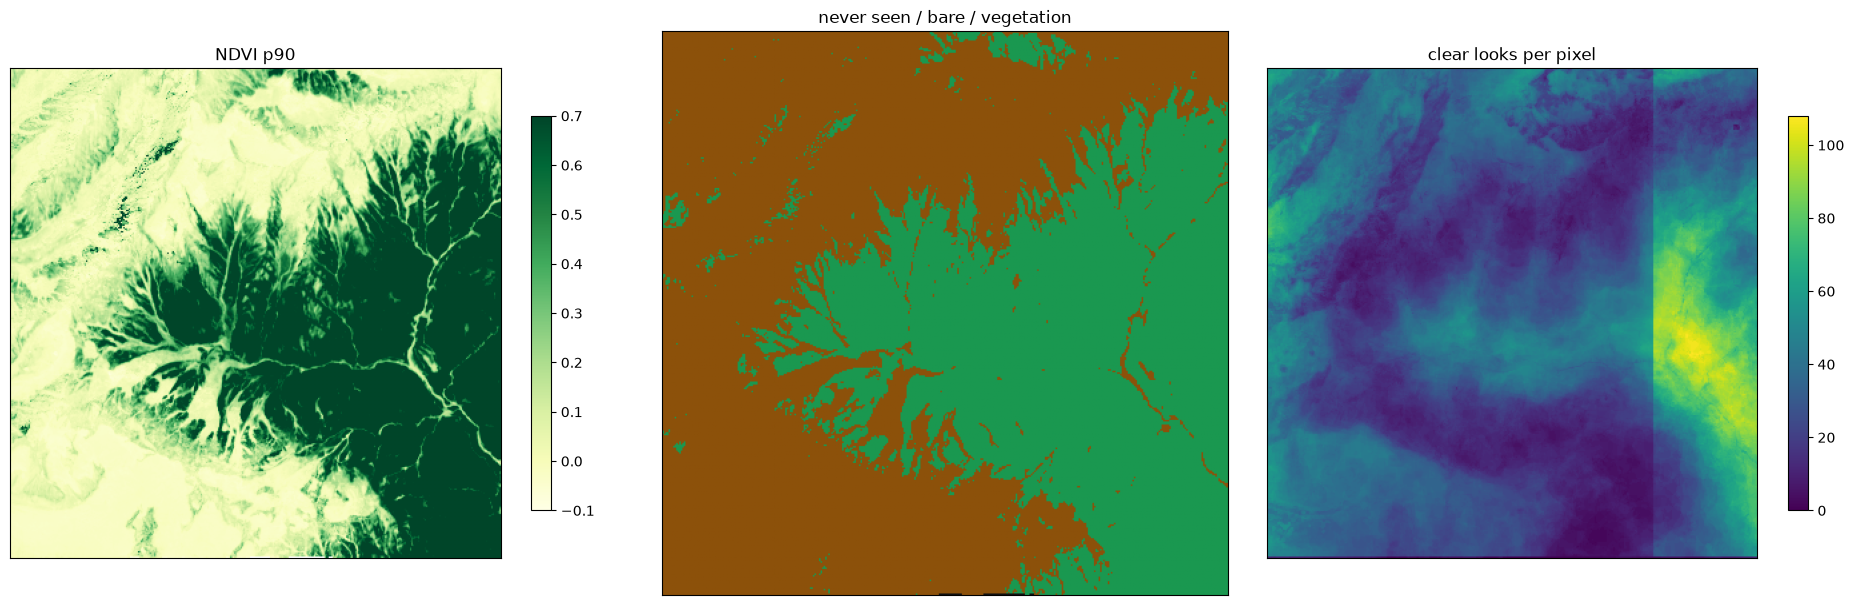

NDVI p5/25/50/75/95: [-0.027  0.017  0.167  0.743  0.878]


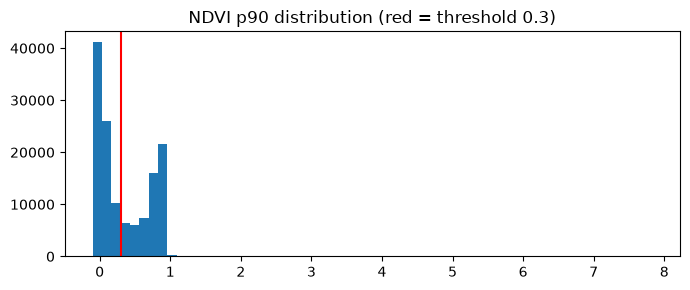

In [6]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(1, 3, figsize=(19, 6))

im0 = ax[0].imshow(ndvi_p, cmap="YlGn", vmin=-0.1, vmax=0.7)
ax[0].set_title(f"NDVI p{PCTL}")
plt.colorbar(im0, ax=ax[0], shrink=0.7)

ax[1].imshow(mask, cmap=mcolors.ListedColormap(["#111111", "#8c510a", "#1a9850"]), vmin=-1, vmax=1)
ax[1].set_title("never seen / bare / vegetation")

im2 = ax[2].imshow(nlooks, cmap="viridis")
ax[2].set_title("clear looks per pixel")
plt.colorbar(im2, ax=ax[2], shrink=0.7)

for a in ax:
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout()
plt.show()

vals = ndvi_p[np.isfinite(ndvi_p)]
print("NDVI p5/25/50/75/95:", np.round(np.percentile(vals, [5, 25, 50, 75, 95]), 3))

plt.figure(figsize=(7, 3))
plt.hist(vals, bins=60)
plt.axvline(NDVI_VEG, c="r")
plt.title(f"NDVI p{PCTL} distribution (red = threshold {NDVI_VEG})")
plt.tight_layout()
plt.show()

## 5. Acquisition inventory

What actually made it into the composite, by year and sensor. Sentinel-2
dominates on revisit frequency; the Landsat pair matters because their overpasses
fall on different days and catch gaps S2 misses.

In [7]:
from collections import Counter

files = sorted((CACHE / "epochs").glob("*.npy"))
by_year   = Counter(f.stem[:4] for f in files)
by_sensor = Counter(f.stem.split("_")[1] for f in files)

print(f"cached NDVI epochs: {len(files)}")
print("by year  :", dict(sorted(by_year.items())))
print("by sensor:", dict(sorted(by_sensor.items())))

cached NDVI epochs: 203
by year  : {'2022': 60, '2023': 80, '2024': 63}
by sensor: {'L8': 29, 'L9': 27, 'S2': 147}


## Outputs

| File | Contents |
|---|---|
| `veg_mask.tif` | `1` vegetation · `0` seen, not vegetation · `-1` never seen clear |
| `ndvi_p90.tif` | the percentile composite itself, for re-thresholding |
| `clear_looks.tif` | clear observations per pixel — the confidence layer |

`clear_looks.tif` is what makes the mask auditable: a vegetation call backed by
sixty clear looks and one backed by two are not the same claim, and the count is
kept so the difference stays visible.

`veg_mask.tif` feeds `landcover_combination.ipynb`, which fuses it with the
perennial snow mask.